# Supplementary Figure S5 — Temporal improvements in cryo-EM RNA base-pair quality

In [1]:
import json
from datetime import datetime
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

_ROOT = Path.cwd().parent.parent
_SUB = "supplemental" if Path.cwd().name == "supplemental_figures" else "main"
FIGURES = _ROOT / "figures" / _SUB

def data_file(rel):
    return _ROOT / "data" / rel

def savefig(fig, name, dpi=150):
    FIGURES.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURES / name, dpi=dpi, bbox_inches="tight")
    return Path("figures") / _SUB / name

In [2]:
COLORS = {"X-ray": "#4A90D9", "EM": "#E55050"}


LABELS = {"X-ray": "X-ray", "EM": "Cryo-EM"}


def _resolution(m):
    return (m.get("EM Diffraction Resolution (Å)") or m.get("Refinement_resolution")
            or m.get("EM Resolution (Å)"))


def _year(s):
    if not s:
        return None
    try:
        return datetime.fromisoformat(s).year
    except Exception:
        return None


def load_temporal_df():
    """Per-structure rows (>=5 pairs) with year, method, resolution, pairs_score."""
    sc = json.load(open(data_file("reference/scores/scores_all_uniques.json")))["scores"]
    vm = json.load(open(data_file("reference/metadata/metadata_cache.json")))["validation_metrics"]
    rows = []
    for pdb, info in sc.items():
        m = vm.get(pdb)
        if not isinstance(m, dict):
            continue
        year = _year(m.get("Deposition_Date"))
        method = m.get("Experimental_method")
        res = _resolution(m)
        if year is None or method not in ("X-ray", "EM") or res is None or res <= 0:
            continue
        rows.append({"pdb": pdb, "year": year, "method": method, "resolution": res,
                     "pairs_score": info["pairs_score"], "n_pairs": info.get("n_pairs", 0)})
    df = pd.DataFrame(rows)
    return df[df["n_pairs"] >= 5].reset_index(drop=True)


def yearly_agg(df):
    agg = (df.groupby(["method", "year"])
             .agg(resolution_mean=("resolution", "mean"), resolution_sem=("resolution", "sem"),
                  pairs_mean=("pairs_score", "mean"), pairs_sem=("pairs_score", "sem"),
                  n=("pdb", "count"))
             .reset_index().sort_values(["method", "year"]))
    for c in ("resolution_sem", "pairs_sem"):
        agg[c] = agg[c].fillna(0)
    return agg


def plot_trend(ax, agg, mean_col, sem_col, ylabel, title, invert_y=False):
    """Yearly-mean trend with per-method points, SEM bars, and linear fits."""
    em_first = int(agg[agg.method == "EM"].year.min())
    box_y = 0.02
    for method in ("X-ray", "EM"):
        sub = agg[agg.method == method].sort_values("year")
        if sub.empty:
            continue
        c = COLORS[method]
        ax.errorbar(sub.year, sub[mean_col], yerr=sub[sem_col], fmt="o-", color=c, ecolor=c,
                    capsize=2.5, alpha=0.9, markersize=6, linewidth=2.2, elinewidth=0.9,
                    label=LABELS[method])
        if len(sub) >= 3:
            res = linregress(sub.year, sub[mean_col])
            xx = np.linspace(sub.year.min(), sub.year.max(), 50)
            ax.plot(xx, res.slope * xx + res.intercept, "--", color=c, linewidth=1.2, alpha=0.8)
            ax.text(0.02, box_y, f"{LABELS[method]}: {res.slope:+.2f}/yr", transform=ax.transAxes,
                    ha="left", va="bottom", fontsize=9, color=c, fontweight="bold",
                    family="monospace",
                    bbox=dict(boxstyle="round", facecolor="white", edgecolor=c, alpha=0.9, linewidth=1.5))
            box_y += 0.08
    ax.axvline(em_first, color="#E55050", linestyle="--", linewidth=1.0, alpha=0.7)
    ax.set_xlabel("Deposition Year", fontweight="bold")
    ax.set_ylabel(ylabel, fontweight="bold")
    ax.set_title(title, fontweight="bold")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right", fontsize=9)
    if invert_y:
        ax.invert_yaxis()

In [3]:
df = load_temporal_df()
agg = yearly_agg(df)
em = df[df['method'] == 'EM'].dropna(subset=['year', 'resolution', 'pairs_score']).copy()

## (A) Average resolution by deposition year

Yearly mean resolution by method.

saved figures/supplemental/figS5_A_resolution_by_year.png


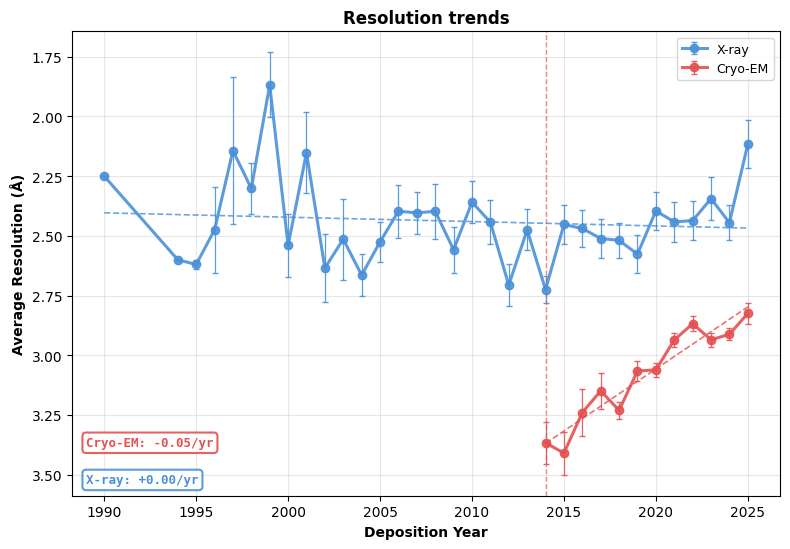

In [4]:
fig, ax = plt.subplots(figsize=(8, 5.6))
plot_trend(ax, agg, 'resolution_mean', 'resolution_sem',
              'Average Resolution (\u00c5)', 'Resolution trends', invert_y=True)
fig.tight_layout(); print('saved', savefig(fig, 'figS5_A_resolution_by_year.png')); plt.show()

## (B) Average pair score by deposition year

Yearly mean pair score by method.

saved figures/supplemental/figS5_B_pair_score_by_year.png


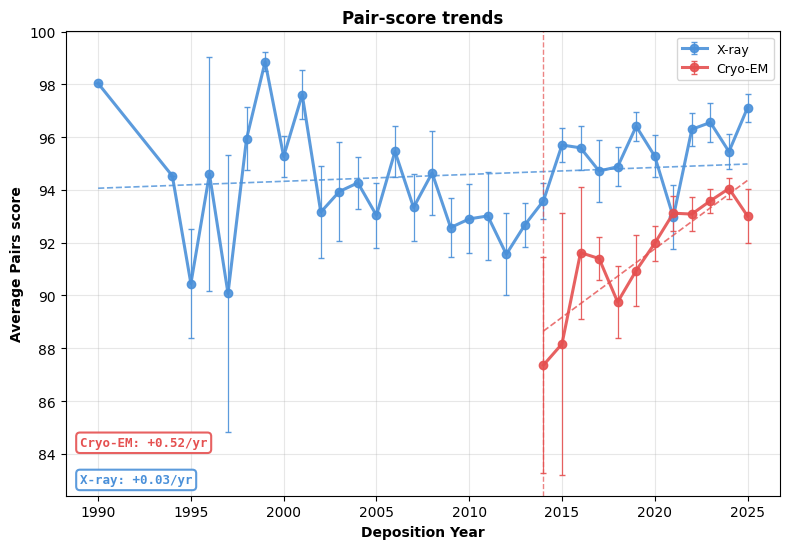

In [5]:
fig, ax = plt.subplots(figsize=(8, 5.6))
plot_trend(ax, agg, 'pairs_mean', 'pairs_sem',
              'Average Pairs score', 'Pair-score trends', invert_y=False)
fig.tight_layout(); print('saved', savefig(fig, 'figS5_B_pair_score_by_year.png')); plt.show()

## (C) Pair-score trend within fixed resolution bands

saved figures/supplemental/figS5_C_trend_within_resolution_bands.png


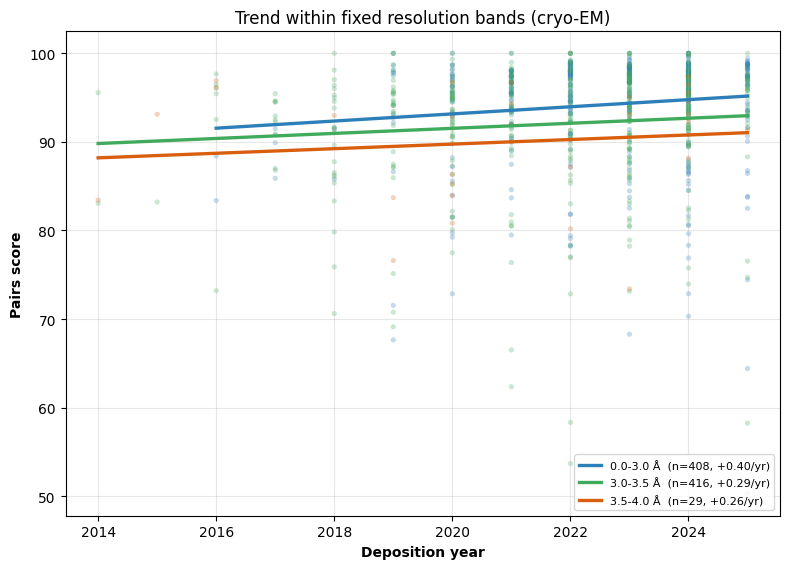

In [6]:
yr = em['year'].to_numpy(float); res = em['resolution'].to_numpy(float); ps = em['pairs_score'].to_numpy(float)
fig, ax = plt.subplots(figsize=(8, 5.8))
for (lo, hi), c in zip([(0, 3.0), (3.0, 3.5), (3.5, 4.0)], ['#2c7fb8', '#41ab5d', '#d95f0e']):
    m = (res >= lo) & (res < hi)
    if m.sum() < 15: continue
    s3, b3 = np.polyfit(yr[m], ps[m], 1)
    ax.scatter(yr[m], ps[m], s=14, alpha=0.28, color=c, edgecolor='none')
    xx = np.linspace(yr[m].min(), yr[m].max(), 50)
    ax.plot(xx, s3*xx + b3, color=c, lw=2.4, zorder=5, label=f'{lo:.1f}-{hi:.1f} \u00c5  (n={m.sum()}, {s3:+.2f}/yr)')
ax.set_xlabel('Deposition year', fontweight='bold'); ax.set_ylabel('Pairs score', fontweight='bold')
ax.set_title('Trend within fixed resolution bands (cryo-EM)'); ax.grid(alpha=0.3)
ax.legend(loc='lower right', fontsize=8)
fig.tight_layout(); print('saved', savefig(fig, 'figS5_C_trend_within_resolution_bands.png')); plt.show()

## (D) Cryo-EM pair score vs year, controlling for resolution

Year effect on pair score after removing resolution.

saved figures/supplemental/figS5_D_partial_regression_year_given_resolution.png


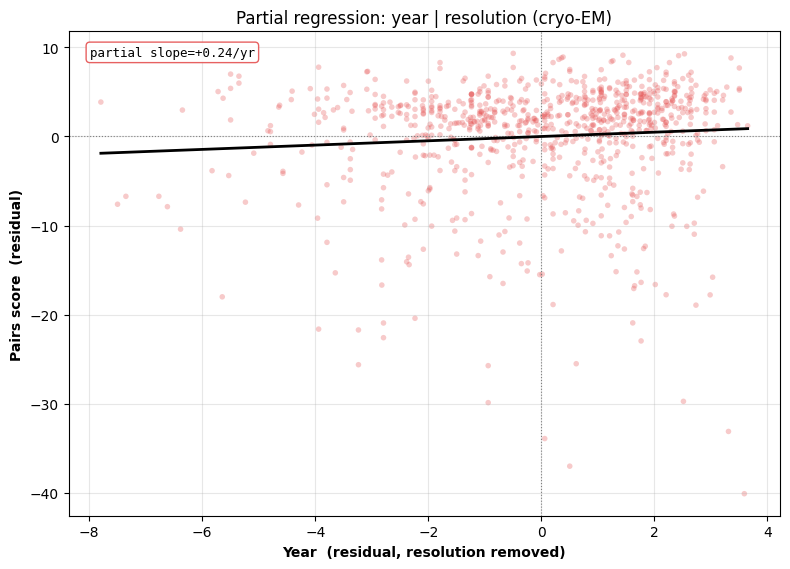

In [7]:
yr = em['year'].to_numpy(float); res = em['resolution'].to_numpy(float); ps = em['pairs_score'].to_numpy(float)
def _resid(v, ctrl):
    X = np.column_stack([np.ones(len(v)), ctrl - ctrl.mean()])
    beta, *_ = np.linalg.lstsq(X, v, rcond=None)
    return v - X @ beta
ry, rp = _resid(yr, res), _resid(ps, res)
s2, b2 = np.polyfit(ry, rp, 1)
fig, ax = plt.subplots(figsize=(8, 5.8))
ax.scatter(ry, rp, s=16, alpha=0.30, color='#E55050', edgecolor='none')
xx = np.linspace(ry.min(), ry.max(), 50); ax.plot(xx, s2*xx + b2, color='black', lw=2, zorder=5)
ax.axhline(0, color='gray', lw=0.8, ls=':'); ax.axvline(0, color='gray', lw=0.8, ls=':')
ax.text(0.03, 0.97, f'partial slope={s2:+.2f}/yr', transform=ax.transAxes,
        va='top', ha='left', family='monospace', fontsize=9,
        bbox=dict(boxstyle='round', fc='white', ec='#E55050', alpha=0.9))
ax.set_xlabel('Year  (residual, resolution removed)', fontweight='bold')
ax.set_ylabel('Pairs score  (residual)', fontweight='bold')
ax.set_title('Partial regression: year | resolution (cryo-EM)'); ax.grid(alpha=0.3)
fig.tight_layout(); print('saved', savefig(fig, 'figS5_D_partial_regression_year_given_resolution.png')); plt.show()